# Nuclear Waste Canister Temperature Prediction — KNN
**CIVIL-226 - Introduction to Machine Learning for Engineers — EPFL**  
**Team name:** [To fill]  
**Members:** NAJA Nour | CLERICI Alessandro

## Objective
Predict the temperature around nuclear waste canisters at unobserved sensor positions using k-Nearest Neighbors regression.

The dataset contains 3 experimental replications per sensor/timestep (different power scenarios). The test set corresponds exclusively to Rep 2 (radioactive decay profile), so we train only on Rep 2 data for consistency.

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

np.random.seed(42)
print('Imports OK')

Imports OK


## 2. Load data

In [2]:
train   = pd.read_parquet('data/train.parquet')
test    = pd.read_parquet('data/test.parquet')
sensors = pd.read_parquet('data/sensors.parquet')

# Remove duplicate sensors (N206, N213 appear twice with identical coordinates)
n_before = len(sensors)
sensors = sensors.drop_duplicates(subset='sensor', keep='first').reset_index(drop=True)
print(f'Duplicate sensors removed: {n_before - len(sensors)}')

print(f'Sensors : {sensors.shape}  ->  {sensors.columns.tolist()}')
print(f'Train   : {train.shape}   ->  {train.columns.tolist()}')
print(f'Test    : {test.shape}    ->  {test.columns.tolist()}')

Duplicate sensors removed: 2
Sensors : (323, 4)  ->  ['sensor', 'coor_x', 'coor_y', 'coor_z']
Train   : (6626928, 4)   ->  ['sensor', 'time', 'power', 'temperature']
Test    : (2190480, 3)    ->  ['sensor', 'time', 'power']


## 3. Merge sensor positions

In [3]:
train_full = train.merge(sensors, on='sensor', how='left')
print(train_full.head())
print(train_full.shape)

  sensor       time        power  temperature     coor_x  coor_y  coor_z
0   N102        0.0  1487.964722    17.514429  46.131474     3.5     0.0
1   N102   864000.0  1487.288818    17.820795  46.131474     3.5     0.0
2   N102  1728000.0  1486.612915    17.573187  46.131474     3.5     0.0
3   N102  2592000.0  1485.936890    16.513235  46.131474     3.5     0.0
4   N102  3456000.0  1485.260986    16.303427  46.131474     3.5     0.0
(6626928, 7)


## 4. Clean missing values

In [4]:
print(f'Rows before NaN removal: {len(train_full)}')
train_full = train_full.dropna(subset=['temperature']).copy()
print(f'Rows after NaN removal : {len(train_full)}')

Rows before NaN removal: 6626928
Rows after NaN removal : 6527525


## 5. Data Exploration

count    6.527525e+06
mean     4.706069e+01
std      3.897674e+02
min     -2.921508e+02
0.1%    -2.921508e+02
1%      -1.495938e+01
5%       3.050485e+00
25%      1.566275e+01
50%      1.939439e+01
75%      2.877052e+01
95%      5.601719e+01
99%      7.570076e+01
99.9%    6.039050e+03
max      6.039050e+03
Name: temperature, dtype: float64
Temperature min: -292.15085
Temperature max: 6039.05


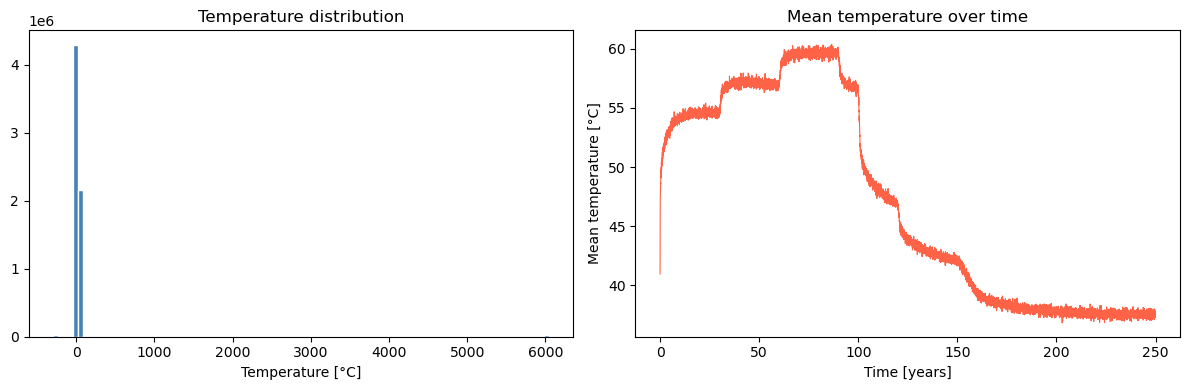

In [5]:
print(train_full['temperature'].describe(percentiles=[0.001, 0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]))
print('Temperature min:', train_full['temperature'].min())
print('Temperature max:', train_full['temperature'].max())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_full['temperature'].dropna(), bins=100, color='steelblue', edgecolor='white')
axes[0].set_title('Temperature distribution')
axes[0].set_xlabel('Temperature [°C]')

temp_by_time = train_full.groupby('time')['temperature'].mean()
axes[1].plot(temp_by_time.index / (365.25*24*3600), temp_by_time.values, color='tomato', linewidth=0.8)
axes[1].set_title('Mean temperature over time')
axes[1].set_xlabel('Time [years]')
axes[1].set_ylabel('Mean temperature [°C]')
plt.tight_layout()
plt.show()

## 6. Outlier Removal

We use two complementary methods from OG_improved:
- **Global MAD** (Median Absolute Deviation): catches sensors with physically impossible temperatures
- **Local IQR per timestep**: catches values that deviate too much from the distribution at a given moment in time

In [6]:
# --- Global outliers via MAD ---
temp = train_full['temperature']
median_temp = temp.median()
mad_temp = np.median(np.abs(temp - median_temp))
robust_z = 0.6745 * (temp - median_temp) / (mad_temp + 1e-8)

train_full['is_global_outlier'] = robust_z.abs() > 6
print(f'Global outliers (MAD): {train_full["is_global_outlier"].sum()}')

Global outliers (MAD): 114636


In [7]:
# --- Local outliers per timestep via IQR ---
time_stats = (
    train_full
    .groupby('time')['temperature']
    .agg(
        time_median='median',
        time_q1=lambda x: x.quantile(0.25),
        time_q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)
time_stats['time_iqr'] = time_stats['time_q3'] - time_stats['time_q1']
train_full = train_full.merge(time_stats, on='time', how='left')

train_full['is_local_outlier'] = (
    (train_full['temperature'] < train_full['time_median'] - 4.0 * train_full['time_iqr']) |
    (train_full['temperature'] > train_full['time_median'] + 4.0 * train_full['time_iqr'])
)
print(f'Local outliers (IQR per timestep): {train_full["is_local_outlier"].sum()}')

Local outliers (IQR per timestep): 106226


In [8]:
# --- Remove outliers ---
before_rows = len(train_full)
train_full = train_full[
    (~train_full['is_global_outlier']) & (~train_full['is_local_outlier'])
].copy()
print(f'Rows removed: {before_rows - len(train_full)} | Remaining: {len(train_full)}')

# Drop temporary diagnostic columns
cols_to_drop = ['is_global_outlier', 'is_local_outlier',
                'time_median', 'time_q1', 'time_q3', 'time_iqr']
train_full = train_full.drop(columns=[c for c in cols_to_drop if c in train_full.columns])

Rows removed: 145193 | Remaining: 6382332


## 7. Sensor Drift Detection & Correction

Some sensors show a systematic linear drift in their residuals over time — i.e. they read progressively higher or lower relative to the global trend. We detect and correct this.

In [9]:
# Global median temperature per timestep
time_median = (
    train_full.groupby('time')['temperature']
    .median()
    .rename('global_time_median')
    .reset_index()
)
drift_df = train_full.merge(time_median, on='time', how='left').copy()
drift_df['temp_residual'] = drift_df['temperature'] - drift_df['global_time_median']

t_min = drift_df['time'].min()
t_max = drift_df['time'].max()
drift_df['time_norm_for_drift'] = (drift_df['time'] - t_min) / (t_max - t_min + 1e-8)

drift_records = []
for sensor_id, g in drift_df.groupby('sensor'):
    g = g.sort_values('time_norm_for_drift')
    if len(g) < 20:
        continue
    x = g['time_norm_for_drift'].values
    y = g['temp_residual'].values
    slope = np.polyfit(x, y, 1)[0] if np.std(y) > 1e-8 else 0.0
    corr  = np.corrcoef(x, y)[0, 1] if np.std(y) > 1e-8 else 0.0
    drift_records.append({'sensor': sensor_id, 'drift_slope': slope, 'drift_corr': corr})

sensor_drift = pd.DataFrame(drift_records)
slope_abs = sensor_drift['drift_slope'].abs()
slope_threshold = slope_abs.median() + 4 * (np.median(np.abs(slope_abs - slope_abs.median())) + 1e-8)
sensor_drift['is_drift_sensor'] = (
    (sensor_drift['drift_slope'].abs() > slope_threshold) &
    (sensor_drift['drift_corr'].abs() > 0.5)
)
drift_sensors = sensor_drift.loc[sensor_drift['is_drift_sensor'], 'sensor'].unique()
print(f'Slope threshold: {slope_threshold:.4f}')
print(f'Drift sensors detected: {len(drift_sensors)}')

Slope threshold: 53.4257
Drift sensors detected: 2


In [10]:
# Apply drift correction
t_min = train_full['time'].min()
t_max = train_full['time'].max()
train_full['time_norm_for_drift'] = (train_full['time'] - t_min) / (t_max - t_min + 1e-8)
drift_map = sensor_drift.set_index('sensor')['drift_slope'].to_dict()
train_full['drift_correction'] = 0.0

for s in drift_sensors:
    mask = train_full['sensor'] == s
    train_full.loc[mask, 'drift_correction'] = (
        drift_map[s] * (train_full.loc[mask, 'time_norm_for_drift'] - 0.5)
    )

train_full['temperature'] = train_full['temperature'] - train_full['drift_correction']
train_full = train_full.drop(columns=['time_norm_for_drift', 'drift_correction'])
print('Drift correction applied.')

Drift correction applied.


## 8. Identify Replication & Filter Rep 2

Each (sensor, timestep) has exactly 3 rows corresponding to 3 experimental replications with different power scenarios:
- **Rep 0**: starts at 500W, drops to 0W around year 100
- **Rep 1**: starts at 1400W, drops to 0W around year 110  
- **Rep 2**: radioactive decay 1488W → 299W over 250 years

The test set corresponds **exclusively to Rep 2**. We therefore train only on Rep 2 to avoid introducing noise from physically incompatible power scenarios.

In [11]:
# Identify replication by power rank at each (sensor, time)
# Rep 2 = highest power (radioactive decay from ~1488W)
train_full['rep'] = (
    train_full.groupby(['sensor', 'time'])['power']
    .rank(method='first')
    .astype(int) - 1
)

for rep in [0, 1, 2]:
    sub = train_full[train_full['rep'] == rep]
    print(f'Rep {rep}: {sub.sensor.nunique()} sensors, {len(sub):,} rows, '
          f'power {sub.power.iloc[0]:.0f}W -> {sub.power.iloc[-1]:.0f}W')

# Keep only Rep 2
train_full = train_full[train_full['rep'] == 2].drop(columns=['rep']).copy()
print(f'\nAfter filtering to Rep 2: {len(train_full):,} rows, {train_full.sensor.nunique()} sensors')

Rep 0: 240 sensors, 2,190,126 rows, power 1363W -> 0W
Rep 1: 240 sensors, 2,172,023 rows, power 1470W -> 0W
Rep 2: 240 sensors, 2,020,183 rows, power 1488W -> 1001W

After filtering to Rep 2: 2,020,183 rows, 240 sensors


## 9. Feature Engineering

We add physics-motivated features:
- **dist_center**: distance from origin (r = sqrt(x²+y²))
- **dist_canister**: distance from estimated canister center
- **is_opa**: zone indicator (buffer vs OPA, threshold at x=1.4m)
- **time_log**: log(1+t) captures the logarithmic thermal diffusion
- **cum_energy**: cumulative energy injected into the system
- **power_over_dist2**: power weighted by inverse square distance (heat flux proxy)
- **diffusion**: dist²/time (diffusion number)

In [12]:
eps = 1e-8

def add_features(df, t_max_ref):
    """
    Add physics-motivated engineered features.
    t_max_ref: max time from training data (for consistent time_norm on test).
    """
    df = df.copy()

    # Spatial features
    df['dist2']        = df['coor_x']**2 + df['coor_y']**2
    df['dist_center']  = np.sqrt(df['dist2'])
    df['dist_canister'] = np.sqrt((df['coor_x'] - 0.7)**2 + (df['coor_y'] - 1.2)**2)
    df['is_opa']       = (df['coor_x'] > 1.4).astype(float)

    # Temporal features
    df['time_log']  = np.log1p(df['time'])
    df['time_norm'] = df['time'] / t_max_ref

    # Physics-motivated features
    df['power_over_dist2'] = df['power'] / (df['dist2'] + eps)
    df['diffusion']        = df['dist2'] / (df['time'] + eps)

    return df


def add_cum_energy(df):
    """
    Compute cumulative energy from power x dt, then merge back.
    Uses drop_duplicates on time to avoid duplication when multiple sensors
    share the same timestep.
    """
    power_time = (
        df[['time', 'power']]
        .drop_duplicates(subset=['time'])
        .sort_values('time')
        .copy()
    )
    power_time['dt']         = power_time['time'].diff().fillna(0)
    power_time['cum_energy'] = (power_time['power'] * power_time['dt']).cumsum()

    return df.merge(
        power_time[['time', 'cum_energy']].drop_duplicates(subset=['time']),
        on='time', how='left'
    )


t_max_ref = train_full['time'].max()

train_full = add_cum_energy(train_full)
train_full = add_features(train_full, t_max_ref)

print('Features after engineering:', train_full.columns.tolist())
print(train_full.shape)

Features after engineering: ['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z', 'cum_energy', 'dist2', 'dist_center', 'dist_canister', 'is_opa', 'time_log', 'time_norm', 'power_over_dist2', 'diffusion']
(2020183, 16)


## 10. Final Checks After Cleaning

In [13]:
print('Final train_full shape:', train_full.shape)
print('Missing values:')
print(train_full.isna().sum())

assert train_full['temperature'].notna().all()
assert np.isfinite(train_full['temperature']).all()
print('All checks passed.')

Final train_full shape: (2020183, 16)
Missing values:
sensor              0
time                0
power               0
temperature         0
coor_x              0
coor_y              0
coor_z              0
cum_energy          0
dist2               0
dist_center         0
dist_canister       0
is_opa              0
time_log            0
time_norm           0
power_over_dist2    0
diffusion           0
dtype: int64
All checks passed.


## 11. Train/Validation Split by Sensor

We split by sensor (not by row) to properly evaluate generalization to unseen sensor positions — which is exactly the test scenario. A row-based split would leak spatial information.

In [14]:
FEATURES = [
    'coor_x', 'coor_y',
    'time_log',
    'power',
    'power_over_dist2',
    'diffusion',
]
TARGET = 'temperature'

unique_sensors = train_full['sensor'].unique()
rng = np.random.default_rng(42)
val_sensors   = rng.choice(unique_sensors, size=int(0.2 * len(unique_sensors)), replace=False)
train_sensors = np.setdiff1d(unique_sensors, val_sensors)

train_df = train_full[train_full['sensor'].isin(train_sensors)].copy()
val_df   = train_full[train_full['sensor'].isin(val_sensors)].copy()

assert set(train_df['sensor']).isdisjoint(set(val_df['sensor']))

print(f'Train sensors: {train_df.sensor.nunique()} | Rows: {len(train_df):,}')
print(f'Val   sensors: {val_df.sensor.nunique()}   | Rows: {len(val_df):,}')

Train sensors: 192 | Rows: 1,617,450
Val   sensors: 48   | Rows: 402,733


## 12. Normalisation

**Critical for KNN**: distance is computed directly on feature values, so features with large scales (e.g. time in seconds ~10⁹) would completely dominate over spatial coordinates (~1-10m). StandardScaler ensures all features contribute equitably to the distance computation.

In [15]:
X_train = train_df[FEATURES].values
y_train = train_df[TARGET].values

X_val   = val_df[FEATURES].values
y_val   = val_df[TARGET].values

# Fit scaler ONLY on training data, then apply to val and test
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)

print(f'X_train: {X_train_s.shape} | X_val: {X_val_s.shape}')
print(f'NaN in X_train_s: {np.isnan(X_train_s).sum()} | Inf: {np.isinf(X_train_s).sum()}')
print(f'NaN in X_val_s:   {np.isnan(X_val_s).sum()} | Inf: {np.isinf(X_val_s).sum()}')

X_train: (1617450, 6) | X_val: (402733, 6)
NaN in X_train_s: 0 | Inf: 0
NaN in X_val_s:   0 | Inf: 0


## 13. Hyperparameter Tuning — Best k

We search for the best k on a subsample for speed, then train the final model on the full training set.

In [16]:
# Subsample for fast k search
sample_size = min(100_000, len(X_train_s))
idx_sample  = np.random.choice(len(X_train_s), sample_size, replace=False)

k_values = [3, 5, 7, 10]
rmse_k   = []

for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k, n_jobs=-1)
    knn.fit(X_train_s[idx_sample], y_train[idx_sample])
    pred = knn.predict(X_val_s[:10_000])  # partial val for speed
    rmse = np.sqrt(mean_squared_error(y_val[:10_000], pred))
    rmse_k.append(rmse)
    print(f'k={k:3d}  ->  RMSE = {rmse:.4f}')

best_k = k_values[np.argmin(rmse_k)]
print(f'\nBest k: {best_k}')

k=  3  ->  RMSE = 1.4185
k=  5  ->  RMSE = 1.3580
k=  7  ->  RMSE = 1.3060
k= 10  ->  RMSE = 1.2479

Best k: 10


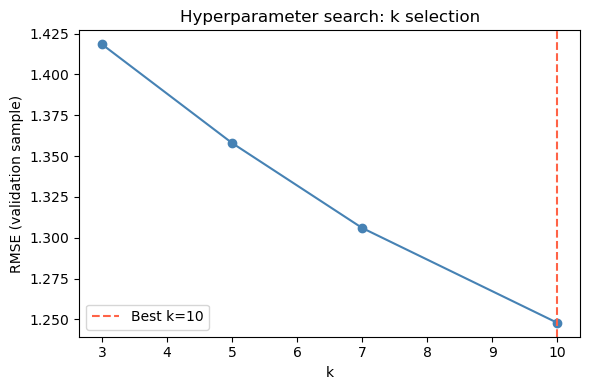

In [17]:
plt.figure(figsize=(6, 4))
plt.plot(k_values, rmse_k, 'o-', color='steelblue')
plt.axvline(best_k, color='tomato', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('k')
plt.ylabel('RMSE (validation sample)')
plt.title('Hyperparameter search: k selection')
plt.legend()
plt.tight_layout()
plt.show()

## 14. Final KNN Training & Evaluation

In [18]:
# Train on full training set with best k
knn_final = KNeighborsRegressor(n_neighbors=best_k, n_jobs=-1)
knn_final.fit(X_train_s, y_train)
print(f'KNN trained with k={best_k} on {len(X_train_s):,} samples.')

KNN trained with k=10 on 1,617,450 samples.


In [19]:
# Evaluate on full validation set
y_val_pred = knn_final.predict(X_val_s)

mae  = mean_absolute_error(y_val, y_val_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2   = r2_score(y_val, y_val_pred)

print(f'Validation MAE  : {mae:.4f} °C')
print(f'Validation RMSE : {rmse:.4f} °C')
print(f'Validation R²   : {r2:.4f}')

Validation MAE  : 3.6513 °C
Validation RMSE : 7.5866 °C
Validation R²   : 0.7199


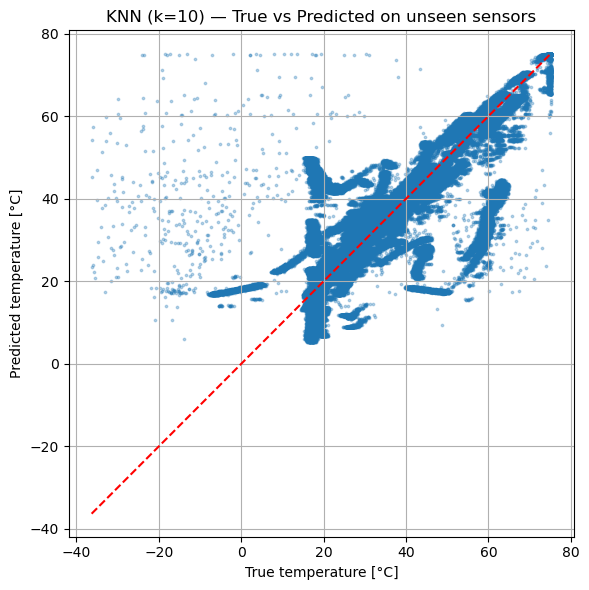

In [20]:
# True vs predicted scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_val_pred, s=3, alpha=0.3)
mn, mx = min(y_val.min(), y_val_pred.min()), max(y_val.max(), y_val_pred.max())
plt.plot([mn, mx], [mn, mx], 'r--')
plt.xlabel('True temperature [°C]')
plt.ylabel('Predicted temperature [°C]')
plt.title(f'KNN (k={best_k}) — True vs Predicted on unseen sensors')
plt.grid(True)
plt.tight_layout()
plt.show()

## 15. Error Analysis by Sensor

In [21]:
val_results = val_df.copy()
val_results['y_true'] = y_val
val_results['y_pred'] = y_val_pred
val_results['abs_error'] = np.abs(y_val - y_val_pred)
val_results['sq_error']  = (y_val - y_val_pred)**2

sensor_metrics = (
    val_results
    .groupby('sensor')
    .agg(
        mae  =('abs_error', 'mean'),
        rmse =('sq_error',  lambda x: np.sqrt(np.mean(x))),
        coor_x=('coor_x', 'first'),
        coor_y=('coor_y', 'first'),
    )
    .sort_values('rmse', ascending=False)
)
print('Worst sensors by RMSE:')
print(sensor_metrics.head(10))

Worst sensors by RMSE:
              mae       rmse     coor_x    coor_y
sensor                                           
N4      24.183138  24.864489   1.400000  0.000000
N201    18.732520  22.126429   0.500000  1.800000
N245    16.097304  19.228771  11.024173  1.068612
N749    16.610374  19.066736  15.646701  0.356862
N928    12.790574  16.611487   0.981864  3.344348
N862    11.220010  13.573458   6.525898  1.996336
N410     9.815307  10.763871  14.933940  0.587954
N528     7.458890   8.599204  33.827808  1.646472
N413     5.211449   8.423906   4.860546  1.365552
N463     6.137942   6.937299   3.446556  0.297682


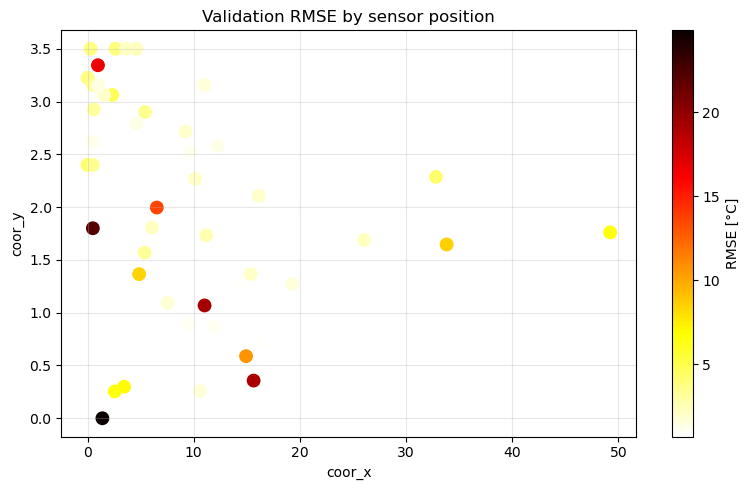

In [22]:
# Spatial error map
plt.figure(figsize=(8, 5))
sc = plt.scatter(
    sensor_metrics['coor_x'],
    sensor_metrics['coor_y'],
    c=sensor_metrics['rmse'],
    cmap='hot_r', s=80
)
plt.colorbar(sc, label='RMSE [°C]')
plt.xlabel('coor_x')
plt.ylabel('coor_y')
plt.title('Validation RMSE by sensor position')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 16. Final Predictions & Submission

In [23]:
# Build test_full with same preprocessing pipeline
test_full = test.merge(sensors, on='sensor', how='left')

# Cumulative energy on test (same logic as train)
test_full = add_cum_energy(test_full)

# Engineered features (using t_max_ref from train for consistent time_norm)
test_full = add_features(test_full, t_max_ref)

print(f'test_full shape: {test_full.shape}')
print(f'Missing values: {test_full[FEATURES].isna().sum().sum()}')

test_full shape: (2190480, 15)
Missing values: 0


In [24]:
# Normalize using the SAME scaler fitted on train
X_test_s = scaler.transform(test_full[FEATURES].values)

assert len(X_test_s) == len(test), 'Test size mismatch!'
print(f'X_test_s: {X_test_s.shape}')

X_test_s: (2190480, 6)


In [26]:
# Predict
y_pred = knn_final.predict(X_test_s)

# Build submission
submission = pd.DataFrame({
    'Id': np.arange(len(test), dtype=int),
    'temperature': y_pred.astype(float)
})

assert list(submission.columns) == ['Id', 'temperature']
assert len(submission) == len(test)
assert np.isfinite(submission['temperature']).all()
assert submission.isna().sum().sum() == 0

submission.to_csv('submission.csv', index=False)
print(f'submission.csv saved — {len(submission)} rows')
display(submission.head())

submission.csv saved — 2190480 rows


,Id,temperature
0,0,17.251059
1,1,17.146826
2,2,17.001398
3,3,17.138629
4,4,17.119443


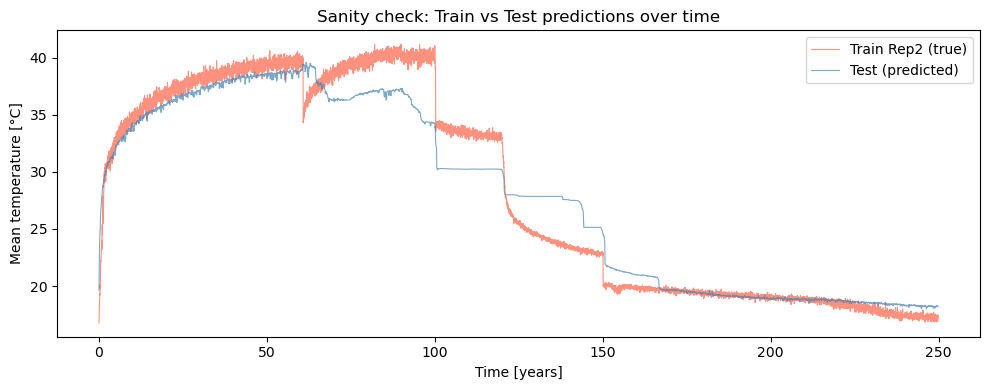

In [27]:
# Visual sanity check: train vs test predictions over time
test_with_pred = test.copy()
test_with_pred['temperature_pred'] = y_pred

temp_train = train_full.groupby('time')['temperature'].mean()
temp_pred  = test_with_pred.groupby('time')['temperature_pred'].mean()

plt.figure(figsize=(10, 4))
plt.plot(temp_train.index / (365.25*24*3600), temp_train.values,
         label='Train Rep2 (true)', color='tomato', alpha=0.7, linewidth=0.8)
plt.plot(temp_pred.index / (365.25*24*3600), temp_pred.values,
         label='Test (predicted)', color='steelblue', alpha=0.7, linewidth=0.8)
plt.title('Sanity check: Train vs Test predictions over time')
plt.xlabel('Time [years]')
plt.ylabel('Mean temperature [°C]')
plt.legend()
plt.tight_layout()
plt.show()

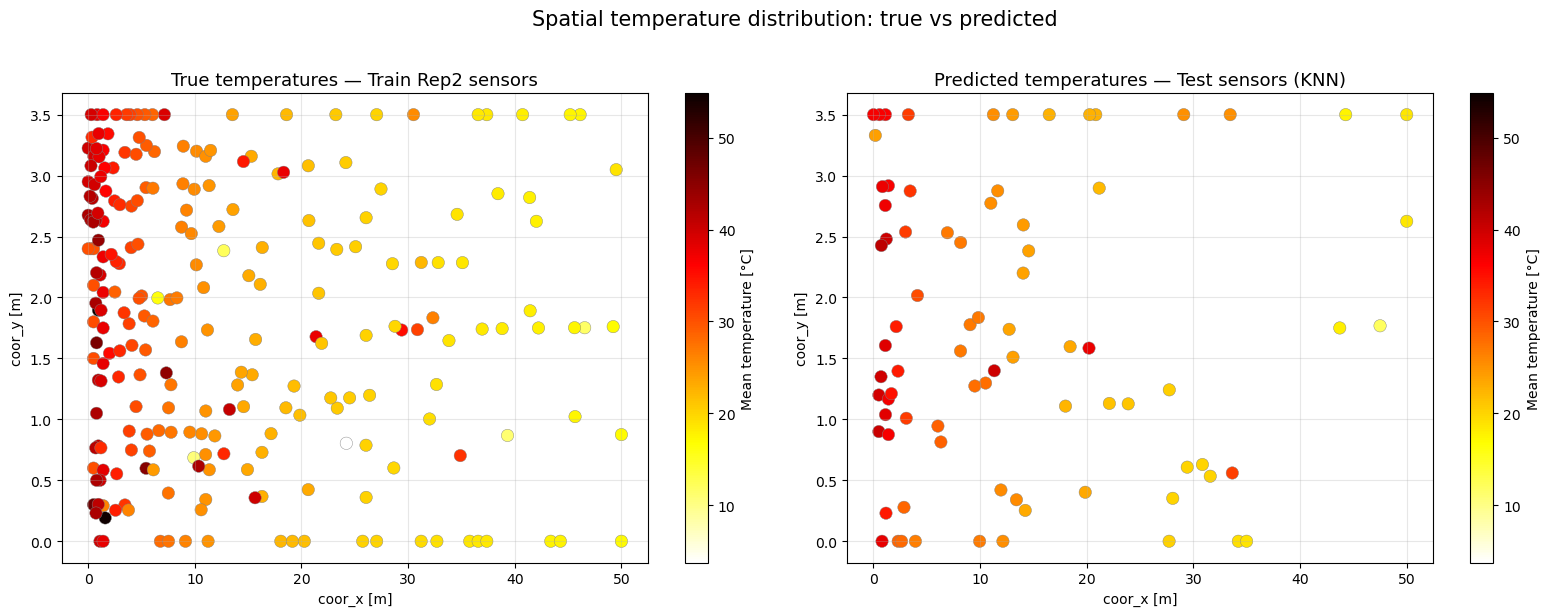

In [28]:
# ============================================================
# Spatial temperature map: true vs predicted
# ============================================================
# We compare the mean temperature per sensor position:
# - Left : true temperatures from train Rep2 (averaged over time)
# - Right: predicted temperatures on test sensors (averaged over time)
# We expect a radial gradient: hot near the canister, cool far away.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: true temperatures (train Rep2 sensors) ---
train_sensor_temp = (
    train_full
    .groupby('sensor')
    .agg(
        coor_x=('coor_x', 'first'),
        coor_y=('coor_y', 'first'),
        mean_temp=('temperature', 'mean')
    )
    .reset_index()
)

vmin = min(train_sensor_temp['mean_temp'].min(),
           test_full.assign(temp_pred=y_pred).groupby('sensor')['temp_pred'].mean().min())
vmax = max(train_sensor_temp['mean_temp'].max(),
           test_full.assign(temp_pred=y_pred).groupby('sensor')['temp_pred'].mean().max())

sc1 = axes[0].scatter(
    train_sensor_temp['coor_x'],
    train_sensor_temp['coor_y'],
    c=train_sensor_temp['mean_temp'],
    cmap='hot_r', vmin=vmin, vmax=vmax,
    s=80, edgecolors='gray', linewidths=0.3
)
axes[0].set_title('True temperatures — Train Rep2 sensors', fontsize=13)
axes[0].set_xlabel('coor_x [m]')
axes[0].set_ylabel('coor_y [m]')
axes[0].grid(True, alpha=0.3)
plt.colorbar(sc1, ax=axes[0], label='Mean temperature [°C]')

# --- Right: predicted temperatures (test sensors) ---
test_full['temp_pred'] = y_pred

test_sensor_temp = (
    test_full
    .groupby('sensor')
    .agg(
        coor_x=('coor_x', 'first'),
        coor_y=('coor_y', 'first'),
        mean_temp=('temp_pred', 'mean')
    )
    .reset_index()
)

sc2 = axes[1].scatter(
    test_sensor_temp['coor_x'],
    test_sensor_temp['coor_y'],
    c=test_sensor_temp['mean_temp'],
    cmap='hot_r', vmin=vmin, vmax=vmax,
    s=80, edgecolors='gray', linewidths=0.3
)
axes[1].set_title('Predicted temperatures — Test sensors (KNN)', fontsize=13)
axes[1].set_xlabel('coor_x [m]')
axes[1].set_ylabel('coor_y [m]')
axes[1].grid(True, alpha=0.3)
plt.colorbar(sc2, ax=axes[1], label='Mean temperature [°C]')

plt.suptitle('Spatial temperature distribution: true vs predicted', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()